In [95]:
# install firedrake

# hide output
%%capture


try:
    from firedrake import *
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    from firedrake import *

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# Patrick's Code

In [97]:
from firedrake import *

N = 4
mesh = SquareMesh(N, N, pi, quadrilateral=False)  # like Fig 3.22

# Should I use Nédélec elements, or Lagrange?
hcurl = False

if hcurl:
    Z = FunctionSpace(mesh, "N1curl", 1)
else:
    Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# This only imposes tangential zero component: Firedrake enforces
# unknown·t = bcdata·t
# for H(curl) function spaces
if hcurl:
    bc = [DirichletBC(Z, Constant((0, 0)), "on_boundary")]
else:
    bc = [DirichletBC(Z.sub(0), 0, (3, 4)),
          DirichletBC(Z.sub(1), 0, (1, 2))]

# Scalar rot
def rot_s(E):
    return E[1].dx(0) - E[0].dx(1)

E = TrialFunction(Z)
F = TestFunction(Z)

a = inner(rot_s(E), rot_s(F))*dx
b = inner(E, F)*dx

problem = LinearEigenproblem(a, b, bcs=bc, restrict=True)
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }
solver = LinearEigensolver(problem, n_evals=50, solver_parameters=sp)

nconv = solver.solve()
eigs = sorted(solver.eigenvalue(i) for i in range(nconv))
for (i, eig) in enumerate(eigs):
    print(BLUE % f"{i:02d} ω²: {eig:.14e}")

  Eigenvalue approximations and residual norms for petsctools_157_ solve.
00 ω²: -5.10702591327572e-15
01 ω²: 2.44249065417534e-15
02 ω²: 4.66293670342566e-15
03 ω²: 2.85592753843783e-01
04 ω²: 5.90333221219484e-01
05 ω²: 6.79540980374944e-01
06 ω²: 7.47064011620181e-01
07 ω²: 7.75201975335959e-01
08 ω²: 1.05246145863534e+00
09 ω²: 1.05413760467427e+00
10 ω²: 2.14591856349089e+00
11 ω²: 2.44774807538279e+00
12 ω²: 4.03725260370563e+00
13 ω²: 4.04300209501191e+00
14 ω²: 4.85050644857734e+00
15 ω²: 4.97955858077311e+00
16 ω²: 5.80268805987405e+00
17 ω²: 6.33785897290139e+00
18 ω²: 6.54838599415266e+00
19 ω²: 9.77688442328386e+00
20 ω²: 1.26183360275717e+01
21 ω²: 1.30215694675164e+01
22 ω²: 1.38825649656100e+01
23 ω²: 1.44098781058373e+01
24 ω²: 1.54636677611099e+01
25 ω²: 1.63937028121320e+01
26 ω²: 1.78207578274134e+01
27 ω²: 2.34556289217467e+01
28 ω²: 2.49240471438433e+01
29 ω²: 3.23210414755931e+01


# My Code - CG1

  Eigenvalue approximations and residual norms for petsctools_159_ solve.


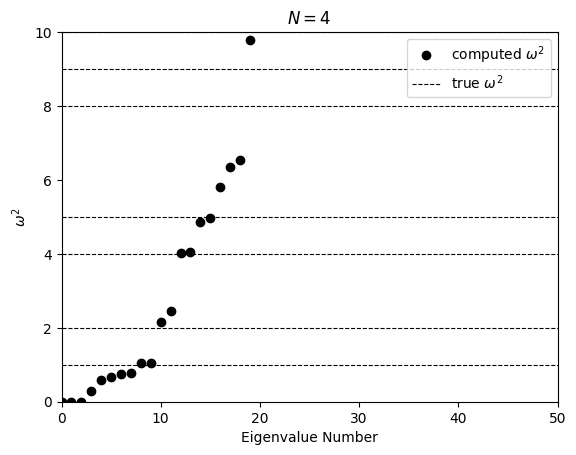

In [98]:
# Set the structured square mesh on (0, pi)
N = 4
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.title(r"$N=4$")
plt.legend()
plt.savefig('Maxwell_CG1_N4.png', dpi=300, bbox_inches="tight")
plt.show()



  Eigenvalue approximations and residual norms for petsctools_161_ solve.


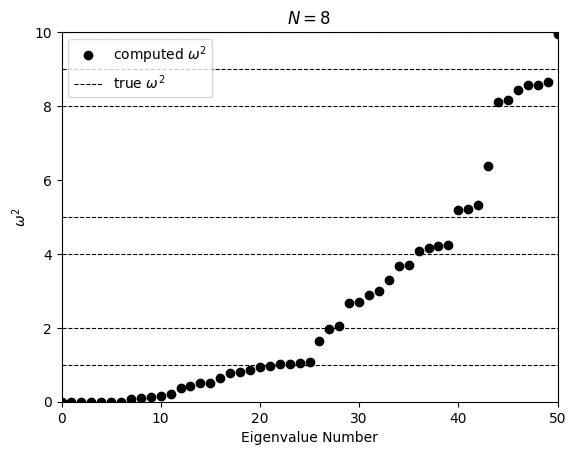

In [99]:
# Set the structured square mesh on (0, pi)
N = 8
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.title(r"$N=8$")
plt.legend()
plt.savefig('Maxwell_CG1_N8.png', dpi=300, bbox_inches="tight")
plt.show()

  Eigenvalue approximations and residual norms for petsctools_163_ solve.
  1 EPS nconv=133 first unconverged value (error) 10.8822 (1.13215641e-10)


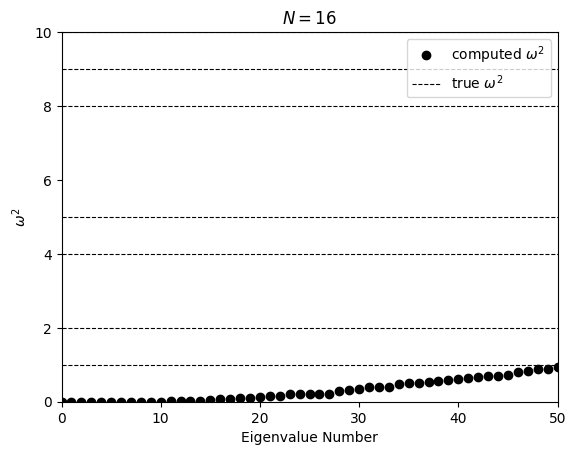

In [100]:
# Set the structured square mesh on (0, pi)
N = 16
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.title(r"$N=16$")
plt.legend()
plt.savefig('Maxwell_CG1_N16.png', dpi=300, bbox_inches="tight")
plt.show()

# My Code - Nedelec

  Eigenvalue approximations and residual norms for petsctools_165_ solve.


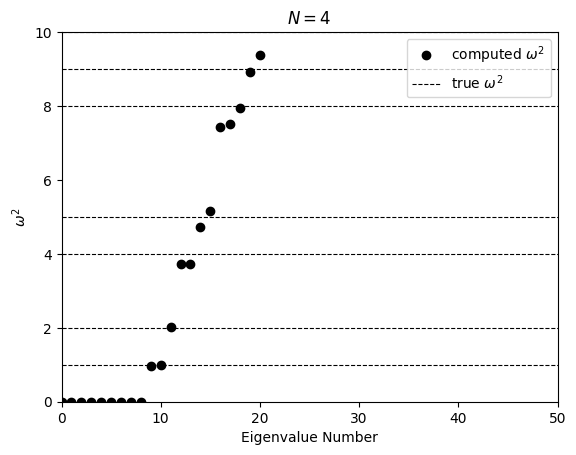

In [101]:
# Set the structured square mesh on (0, pi)
N = 4
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Nedelec space
Z = FunctionSpace(mesh, "N1curl", 1)

# Set zero tangential component
bcs = [DirichletBC(Z, Constant((0,0)), "on_boundary")]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.title(r"$N=4$")
plt.legend()
plt.savefig('Maxwell_Nedelec_N4.png', dpi=300, bbox_inches="tight")
plt.show()


  Eigenvalue approximations and residual norms for petsctools_167_ solve.


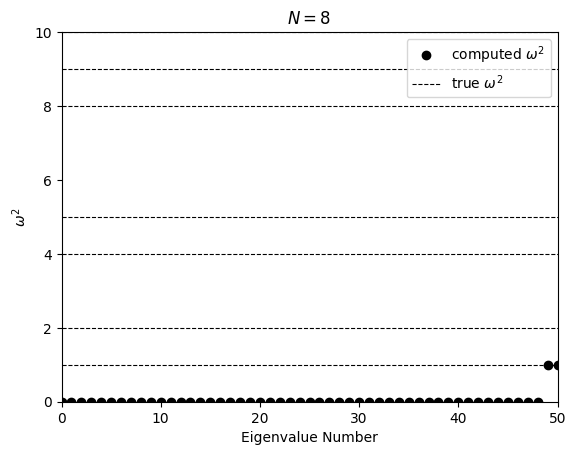

In [102]:
# Set the structured square mesh on (0, pi)
N = 8
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Nedelec space
Z = FunctionSpace(mesh, "N1curl", 1)

# Set zero tangential component
bcs = [DirichletBC(Z, Constant((0,0)), "on_boundary")]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.title(r"$N=8$")
plt.legend()
plt.savefig('Maxwell_Nedelec_N8.png', dpi=300, bbox_inches="tight")
plt.show()

  Eigenvalue approximations and residual norms for petsctools_169_ solve.
  1 EPS nconv=101 first unconverged value (error) 79.0398 (1.30668317e-10)


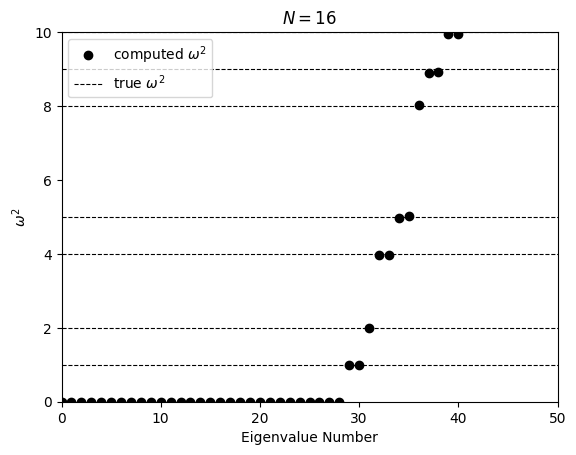

In [103]:
# Set the structured square mesh on (0, pi)
N = 16
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Nedelec space
Z = FunctionSpace(mesh, "N1curl", 1)

# Set zero tangential component
bcs = [DirichletBC(Z, Constant((0,0)), "on_boundary")]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.title(r"$N=16$")
plt.legend()
plt.savefig('Maxwell_Nedelec_N16.png', dpi=300, bbox_inches="tight")
plt.show()